In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV , train_test_split ,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier , plot_tree
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
df = pd.read_csv("output.csv")

In [3]:
df

,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_Services,Is_Solo,Is_Auto_Pay,Short_Contract,Charge_Spike
0,0,1,DSL,No,Yes,No,No,No,No,Yes,Electronic check,29.85,29.85,0,1,0,0,1,0.029820
1,0,34,DSL,Yes,No,Yes,No,No,No,No,Mailed check,56.95,1889.50,0,2,1,0,0,1.378105
2,0,2,DSL,Yes,Yes,No,No,No,No,Yes,Mailed check,53.85,108.15,1,2,1,0,1,-0.197976
3,0,45,DSL,Yes,No,Yes,Yes,No,No,No,Bank transfer (automatic),42.30,1840.75,0,3,1,1,0,1.395353
4,0,2,Fiber optic,No,No,No,No,No,No,Yes,Electronic check,70.70,151.65,1,0,1,0,1,-5.087106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,Mailed check,84.80,1990.50,0,5,0,0,0,1.865956
7028,0,72,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,Credit card (automatic),103.20,7362.90,0,4,0,1,0,0.938920
7029,0,11,DSL,Yes,No,No,No,No,No,Yes,Electronic check,29.60,346.45,0,1,0,0,1,-1.892592
7030,1,4,Fiber optic,No,No,No,No,No,No,Yes,Mailed check,74.40,306.60,1,0,0,0,1,-2.230842


#### Target ANd feature

In [4]:
X_raw = df.drop('Churn', axis=1) 
y = df['Churn'].astype(int)

# One-Hot Encode (dtype=int makes the output 0 and 1 instead of True/False!)
X = pd.get_dummies(X_raw, drop_first=True, dtype=int)

print(f"Features shape after encoding: {X.shape}")

Features shape after encoding: (7032, 21)


In [5]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Total_Services,Is_Solo,Is_Auto_Pay,Short_Contract,Charge_Spike,InternetService_Fiber optic,...,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1,0,0,1,0.029820,0,...,0,1,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,2,1,0,0,1.378105,0,...,1,0,1,0,0,0,0,0,0,1
2,0,2,53.85,108.15,2,1,0,1,-0.197976,0,...,1,1,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,3,1,1,0,1.395353,0,...,1,0,1,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,1,0,1,-5.087106,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,5,0,0,0,1.865956,0,...,1,0,1,1,1,1,1,0,0,1
7028,0,72,103.20,7362.90,4,0,1,0,0.938920,1,...,0,1,1,0,1,1,1,1,0,0
7029,0,11,29.60,346.45,1,0,0,1,-1.892592,0,...,1,0,0,0,0,0,1,0,1,0
7030,1,4,74.40,306.60,0,0,0,1,-2.230842,1,...,0,0,0,0,0,0,1,0,0,1


In [6]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int64

#### Spliting data into Training and Testing

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X , y, test_size = 0.2 , stratify =y)

#### Applying Standardscaler

In [8]:
std_sc = StandardScaler()

In [9]:
# Define all continuous numeric columns that need scaling
cols_to_scale = ["MonthlyCharges", "TotalCharges", "tenure", "Charge_Spike"]

# Fit and transform the training data
X_train[cols_to_scale] = std_sc.fit_transform(X_train[cols_to_scale])

# ONLY transform the testing data
X_test[cols_to_scale] = std_sc.transform(X_test[cols_to_scale])

#### LogisticRegression

In [10]:
Lr = LogisticRegression()

In [11]:
Lr.fit(X_train , y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_pred_lr = Lr.predict(X_test)

In [13]:
print(classification_report(y_test , y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1033
           1       0.68      0.56      0.61       374

    accuracy                           0.81      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.80      0.81      0.81      1407



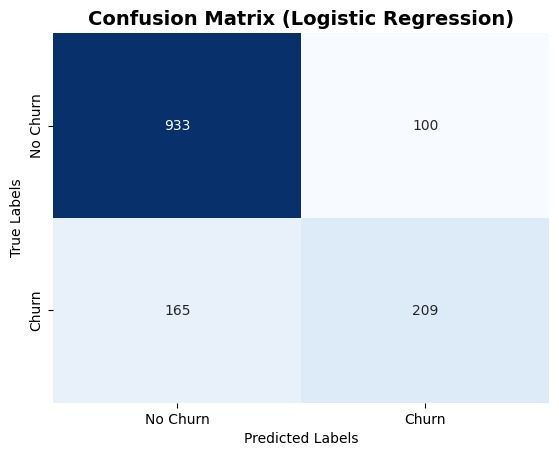

In [14]:
cm = confusion_matrix(y_test, y_pred_lr)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()

- TN = 934 (correctly predicted class 0)
- FP = 99 (predicted 1 but actually 0)
- FN = 168 (missed class 1 ❗ important)
- TP = 206 (correctly predicted class 1)
- key insights our model is good for predicting 0 but week to predict 1

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[933, 100],
       [165, 209]])

## 📊 Logistic Regression Model Evaluation

### 🔹 Model Performance Summary
- The Logistic Regression model achieved an **accuracy of 81%** on the test dataset.
- Due to **class imbalance** (Class 0: 1033 vs Class 1: 374), accuracy alone is not a reliable metric.

---

### 🔹 Confusion Matrix Insights
- **True Positives (TP):** 206  
- **True Negatives (TN):** 934  
- **False Positives (FP):** 99  
- **False Negatives (FN):** 168  

👉 The model performs well in predicting the **negative class**, but struggles with the **positive class**.

---

### 🔹 Class-wise Performance

#### Class 0 (Majority Class)
- Precision: **0.85**
- Recall: **0.90**
- F1-score: **0.87**  
✅ Strong performance

#### Class 1 (Minority Class)
- Precision: **0.68**
- Recall: **0.55**
- F1-score: **0.61**  
⚠️ The model misses a significant number of actual positive cases

---

### 🚨 Key Observations
- The model has a **high number of False Negatives (168)**.
- This indicates poor detection of the **positive class**, which may be critical depending on the domain (e.g., disease prediction).
- The model is **biased toward the majority class**.

---

### ⚠️ Limitations
- Performance is impacted by **class imbalance**
- Logistic Regression assumes **linear relationships**, which may limit model performance


#### Usaing Updated LR Model

#### Hyper Parameter Optimisation for Lr model

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

param_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100]
    }
]

grid_search_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_search_log.fit(X_train, y_train)

print("\n--- Best Parameters ---")
print(grid_search_log.best_params_)
print("Best CV Score:", grid_search_log.best_score_)

best_log_model = grid_search_log.best_estimator_

y_pred = best_log_model.predict(X_test)
y_prob = best_log_model.predict_proba(X_test)[:, 1]

print("\n--- Performance ---")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Best Parameters ---
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.7959866220735786

--- Performance ---
[[751 282]
 [ 76 298]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

ROC-AUC: 0.8470319043748802


              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



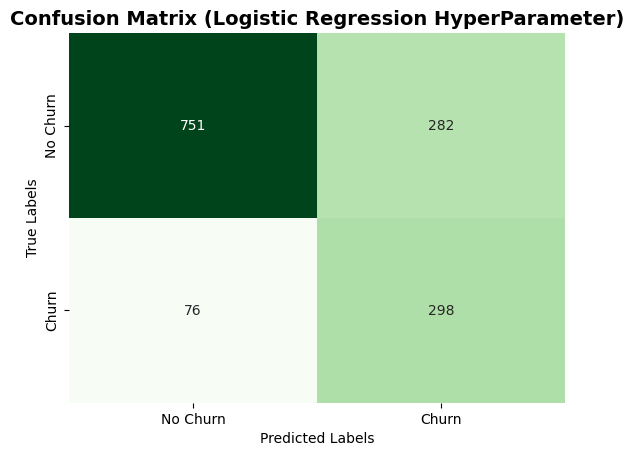

In [17]:
cm = confusion_matrix(y_test, y_pred)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Logistic Regression HyperParameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred))

plt.show()

### Custome ThreshHold FOr LogisticRegression

In [18]:
# -------------------------------
# 1. Model + GridSearch
# -------------------------------
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

param_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100]
    }
]

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n--- Best Parameters ---")
print(grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# -------------------------------
# 2. Best Model
# -------------------------------
best_model = grid_search.best_estimator_

# -------------------------------
# 3. Default Prediction
# -------------------------------
y_pred_default = best_model.predict(X_test)

print("\n--- Default Threshold (0.5) ---")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

# -------------------------------
# 4. Probability Scores
# -------------------------------
y_prob = best_model.predict_proba(X_test)[:, 1]

# -------------------------------
# 5. Find Best Threshold (AUTO)
# -------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Remove last value mismatch issue
precision = precision[:-1]
recall = recall[:-1]

# Compute F1 safely
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

print("\n--- Best Threshold Selection ---")
print("Best Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1 Score:", best_f1)

# -------------------------------
# 6. Final Prediction (Best Threshold)
# -------------------------------
y_pred_best = (y_prob >= best_threshold).astype(int)

print("\n--- Final Model (Optimized Threshold) ---")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

# -------------------------------
# 7. ROC-AUC Score
# -------------------------------
roc_score = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_score)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Best Parameters ---
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.6315686121423083

--- Default Threshold (0.5) ---
[[751 282]
 [ 76 298]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407


--- Best Threshold Selection ---
Best Threshold: 0.6437155416078884
Precision: 0.6064814814814815
Recall: 0.7005347593582888
F1 Score: 0.6501240694291671

--- Final Model (Optimized Threshold) ---
[[863 170]
 [112 262]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1033
           1       0.61      0.70      0.65       374

    accuracy                           0.80      1407
   mac

              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1033
           1       0.61      0.70      0.65       374

    accuracy                           0.80      1407
   macro avg       0.75      0.77      0.75      1407
weighted avg       0.81      0.80      0.80      1407



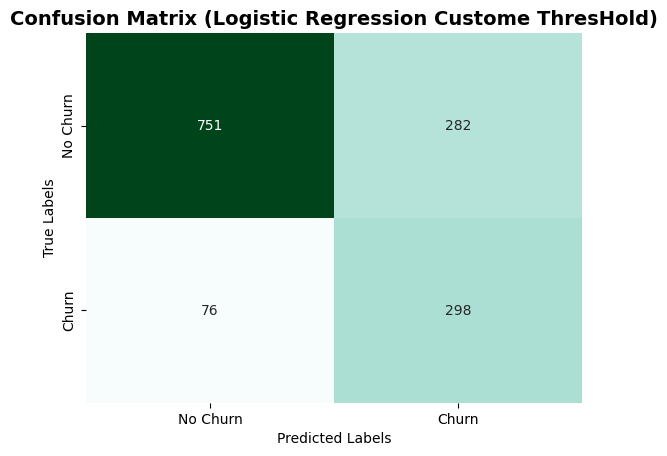

In [19]:
cm = confusion_matrix(y_test, y_pred)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='BuGn',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Logistic Regression Custome ThresHold)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_best))

plt.show()

### DecisionTreeClassifier

In [20]:
dt = DecisionTreeClassifier()

In [21]:
dt.fit(X_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [22]:
y_pred_dt = dt.predict(X_test)

In [23]:
print(confusion_matrix(y_test , y_pred_dt))

[[841 192]
 [174 200]]


In [24]:
print(classification_report(y_test , y_pred_dt))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1033
           1       0.51      0.53      0.52       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1033
           1       0.51      0.53      0.52       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



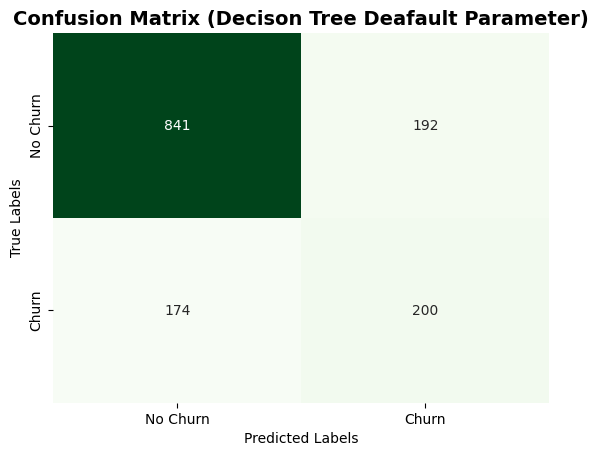

In [25]:
cm = confusion_matrix(y_test, y_pred_dt)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Decison Tree Deafault Parameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_dt))

plt.show()

### Usind HyperPara for DicisionTree

In [26]:
# -------------------------------
# 1. Model
# -------------------------------
dec_t = DecisionTreeClassifier(random_state=42)

# -------------------------------
# 2. Hyperparameter Grid
# -------------------------------
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', None]
}

# -------------------------------
# 3. GridSearch
# -------------------------------
grid_search_DT = GridSearchCV(
    estimator=dec_t,
    param_grid=param_grid_dt,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_search_DT.fit(X_train, y_train)

print("\n--- Best Parameters (Decision Tree) ---")
print(grid_search_DT.best_params_)
print("Best CV Score:", grid_search_DT.best_score_)

# -------------------------------
# 4. Best Model
# -------------------------------
best_dt = grid_search_DT.best_estimator_

# -------------------------------
# 5. Predictions
# -------------------------------
y_pred_dt = best_dt.predict(X_test)

print("\n--- Decision Tree Performance ---")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

--- Best Parameters (Decision Tree) ---
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Score: 0.7939799331103679

--- Decision Tree Performance ---
[[780 253]
 [ 90 284]]
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



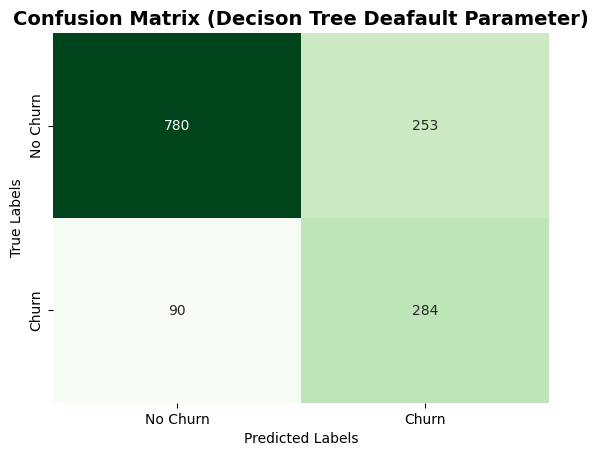

In [27]:
cm = confusion_matrix(y_test, y_pred_dt)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Decison Tree Deafault Parameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_dt))

plt.show()

In [28]:
# -------------------------------
# 1. Model
# -------------------------------
dec_t = DecisionTreeClassifier(random_state=42)

# -------------------------------
# 2. Hyperparameter Grid
# -------------------------------
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', None]
}

# -------------------------------
# 3. GridSearch
# -------------------------------
grid_search_DT = GridSearchCV(
    estimator=dec_t,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_DT.fit(X_train, y_train)

print("\n--- Best Parameters ---")
print(grid_search_DT.best_params_)
print("Best CV Score:", grid_search_DT.best_score_)

# -------------------------------
# 4. Best Model
# -------------------------------
best_dt = grid_search_DT.best_estimator_

# -------------------------------
# 5. Default Prediction (0.5)
# -------------------------------
y_pred_default = best_dt.predict(X_test)

print("\n--- Default Threshold (0.5) ---")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

# -------------------------------
# 6. Get Probabilities
# -------------------------------
y_prob = best_dt.predict_proba(X_test)[:, 1]

# -------------------------------
# 7. Try Manual Thresholds
# -------------------------------
print("\n--- Manual Threshold Testing ---")
for t in [0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))

# -------------------------------
# 8. Auto Best Threshold (F1)
# -------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# align arrays
precision = precision[:-1]
recall = recall[:-1]

# F1 calculation
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\n--- Best Threshold (AUTO) ---")
print("Threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1 Score:", f1_scores[best_idx])

# -------------------------------
# 9. Final Prediction (Best Threshold)
# -------------------------------
y_pred_best = (y_prob >= best_threshold).astype(int)

print("\n--- Final Decision Tree (Optimized Threshold) ---")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

# -------------------------------
# 10. ROC-AUC Score
# -------------------------------
roc_score = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_score)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

--- Best Parameters ---
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.6189891468165525

--- Default Threshold (0.5) ---
[[754 279]
 [ 84 290]]
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.76      1407


--- Manual Threshold Testing ---

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.76      1407


Thr

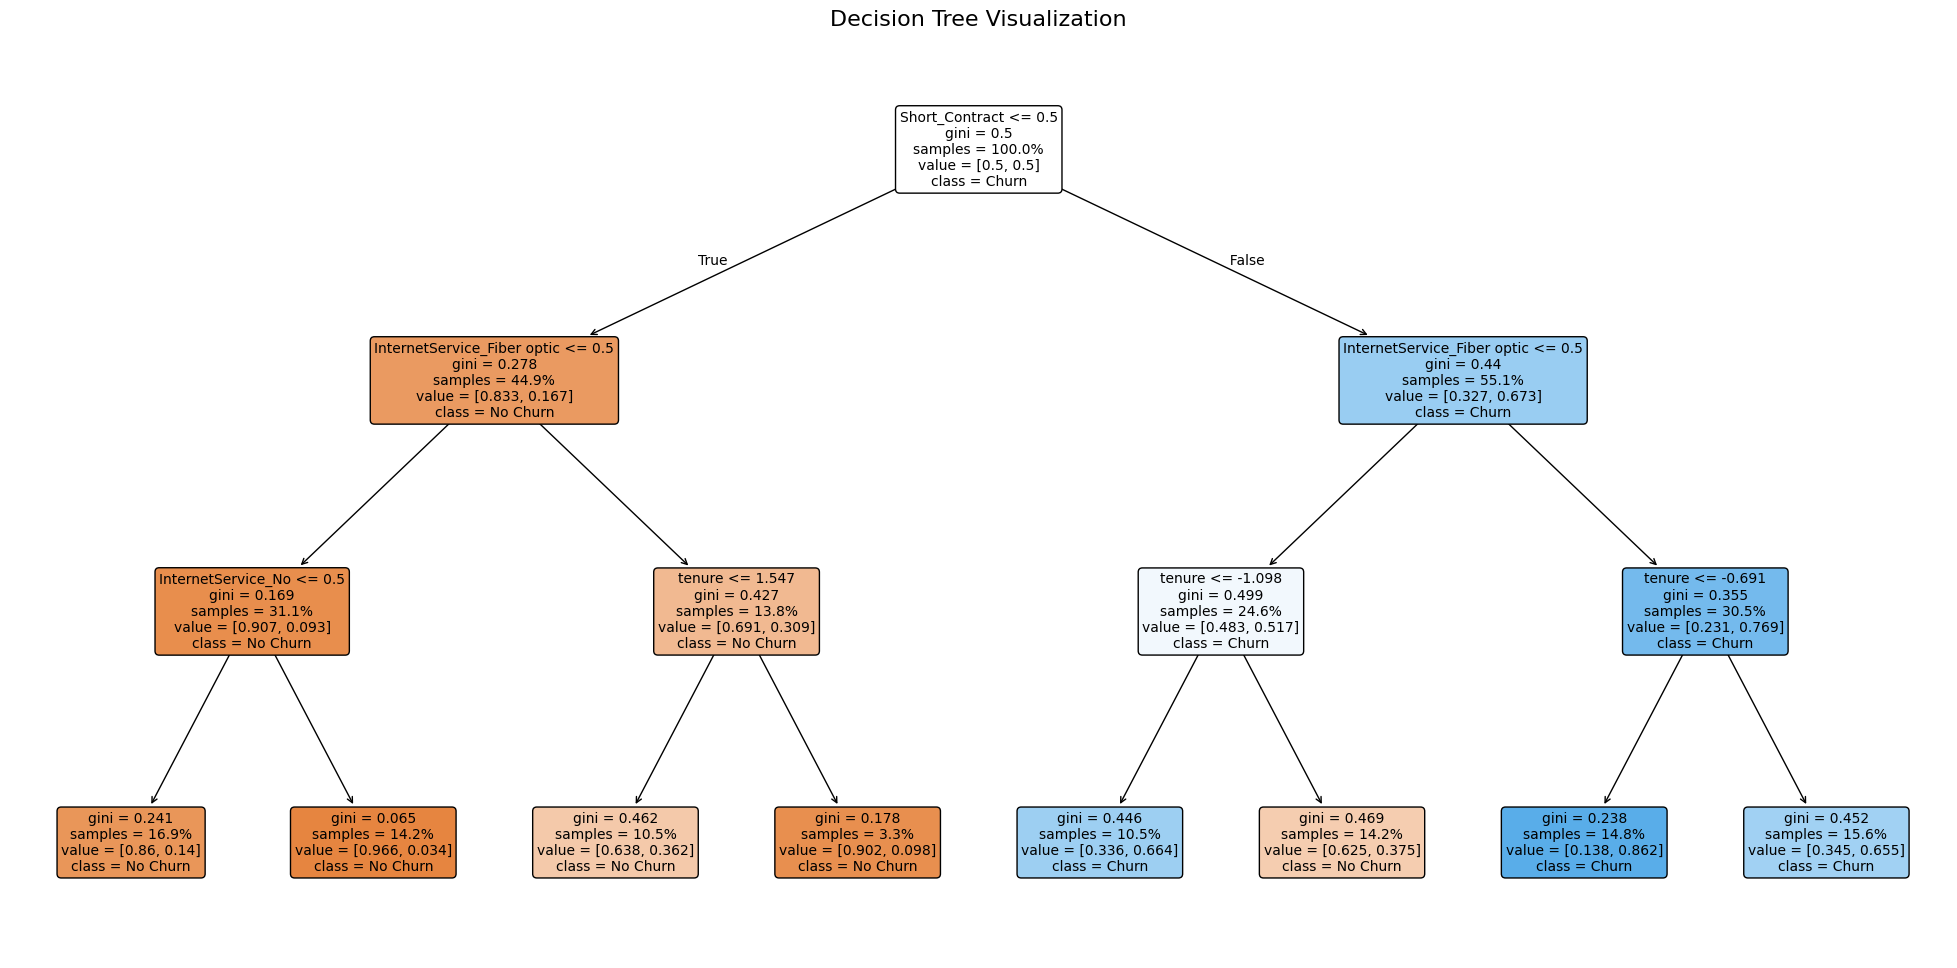

In [29]:
plt.figure(figsize=(25,12))

plot_tree(
    best_dt,
    filled=True,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    rounded=True,
    fontsize=10,
    proportion=True
)

plt.title("Decision Tree Visualization", fontsize=16)
plt.show()

### RandomForestClassifier

In [30]:
RF = RandomForestClassifier()

In [31]:
RF.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred_rf =  RF.predict(X_test)

In [33]:
print(confusion_matrix(y_test , y_pred_rf))

[[913 120]
 [198 176]]


In [34]:
print(classification_report(y_test , y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.59      0.47      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.59      0.47      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



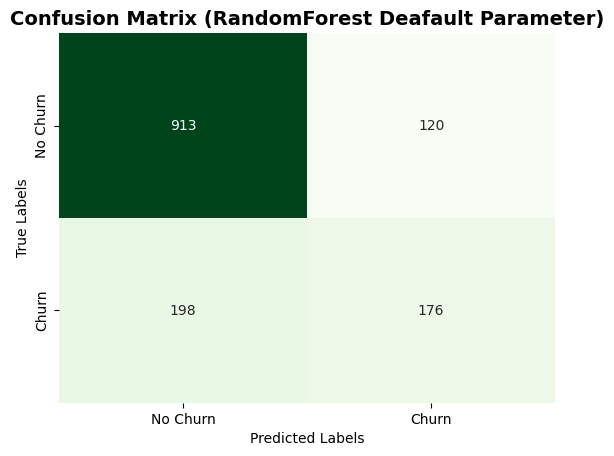

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (RandomForest Deafault Parameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_rf))

plt.show()

### HyperPrameter Randomforest 

In [36]:
rf_1  = RandomForestClassifier(random_state=42, n_jobs=-1)



param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False],                 # use bootstrap samples
    'class_weight': ['balanced', None]          # handle class imbalance
}


In [37]:
# Model
rf_1 = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 300],              # reduce for speed
    'max_depth': [None, 10, 20],             # avoid too shallow
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],           # remove 10 (too restrictive)
    'max_features': ['sqrt', 'log2'],        # remove None (can overfit)
    'criterion': ['gini'],                   # faster, similar performance
    'bootstrap': [True],                     # usually best
    'class_weight': [
        {0:1, 1:1},      # balanced
        {0:1, 1:1.5},    # slight recall boost
        {0:1, 1:2},      # strong recall
        {0:1.5, 1:1}     # 🔥 precision boost (IMPORTANT)
    ]
}

In [38]:
# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_1,
    param_distributions=param_grid_rf,
    n_iter=50,              # 🔥 try 30–50 (fast + good results)
    scoring='recall',       # your metric
    cv=3,                   # 🔥 reduce from 5 → 3 for speed
    verbose=2,              # shows progress
    random_state=42,
    n_jobs=-1
)


In [39]:

# Fit model
random_search.fit(X_train, y_train)

# Best results
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'gini', 'class_weight': {0: 1, 1: 2}, 'bootstrap': True}
Best Score: 0.6562160465509331


In [40]:
y_pred_rf  = random_search.predict(X_test)

In [41]:
print(confusion_matrix(y_test  , y_pred_rf))

[[843 190]
 [116 258]]


In [42]:
print(classification_report(y_test  , y_pred_rf)) 

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.69      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.69      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



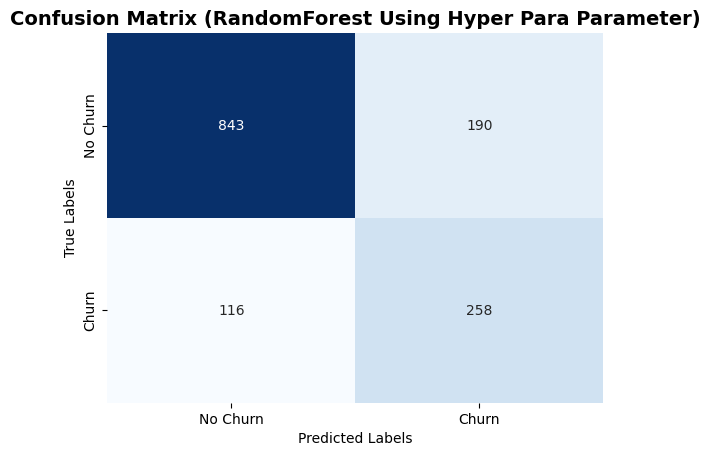

In [43]:
cm = confusion_matrix(y_test, y_pred_rf)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (RandomForest Using Hyper Para Parameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_rf))

plt.show()

#### Xtream Gradien Boost 

In [44]:
# 1. Calculate class imbalance to help the model pay attention to the "Churners"
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale Pos Weight (Imbalance Ratio): {scale_pos_weight:.2f}")

# 2. Initialize the XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight, # Handles the imbalanced data
    reg_alpha=0.1,
    reg_lambda=1,
    gamma=0.1,
    random_state=42,
    eval_metric="logloss"
)

Scale Pos Weight (Imbalance Ratio): 2.76


In [45]:

# 3. Train the Model!
print("Training the XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Training complete!\n")

Training the XGBoost model...
Training complete!



In [46]:
# 4. Make Predictions on the Test Set
y_pred = xgb_model.predict(X_test)

In [47]:
# 5. Evaluate the Results

print("=== FINAL MODEL REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

=== FINAL MODEL REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407


=== CONFUSION MATRIX ===
[[810 223]
 [101 273]]


              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.69      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



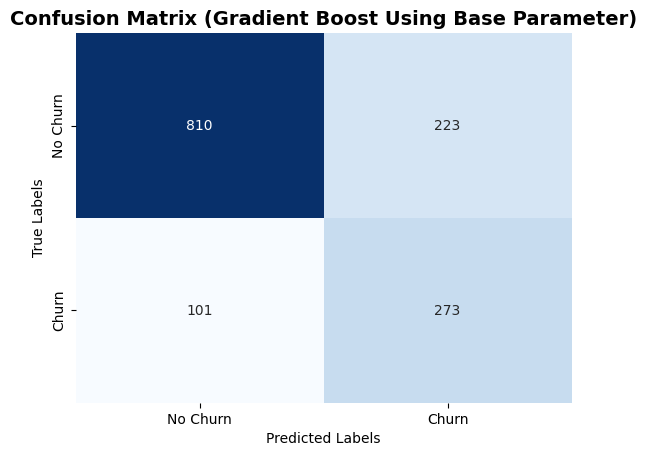

In [48]:
cm = confusion_matrix(y_test, y_pred)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Gradient Boost Using Base Parameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_rf))

plt.show()

#### Hyper Para GradientBoost

In [49]:
param_grid = {
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0.1, 0.2],
    'scale_pos_weight': [scale_pos_weight] # Use the ratio you calculated
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(n_estimators=500, random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1', # F1 balances precision and recall perfectly
    cv=3,
    n_jobs=-1,
    verbose=1
)


In [50]:

# 1. Start the Tuning Process
print("Starting Grid Search... This will find the best version of your XGBoost model.")
grid_search.fit(X_train, y_train)

Starting Grid Search... This will find the best version of your XGBoost model.
Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0.1, 0.2], 'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [51]:

# 2. Extract the Best Hyperparameters
print("\n--- Best Parameters Found ---")
print(grid_search.best_params_)


--- Best Parameters Found ---
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 5, 'scale_pos_weight': 2.762541806020067, 'subsample': 0.8}


In [52]:
# 3. Save the Best Model for Predictions
best_xgb_model = grid_search.best_estimator_

In [53]:

# 4. Make Predictions on the Unseen Test Set
y_pred_best = best_xgb_model.predict(X_test)

In [54]:

# 5. Final Professional Evaluation
print("\n--- Final Performance of Best Tuned Model ---")
print(classification_report(y_test, y_pred_best))

# 6. Check the Confusion Matrix for the Best Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


--- Final Performance of Best Tuned Model ---
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407

Confusion Matrix:
[[759 274]
 [ 75 299]]


              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



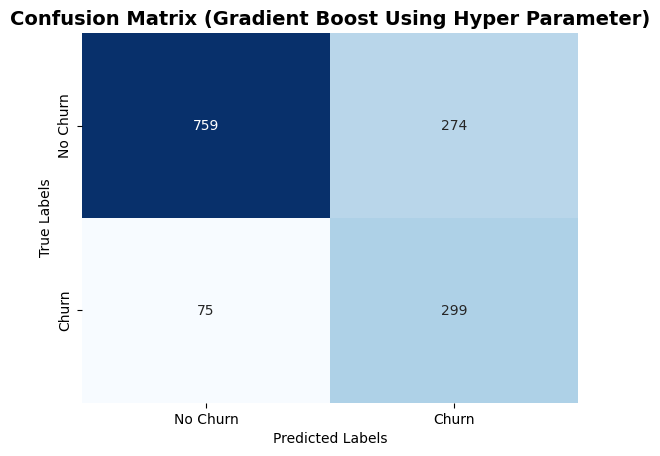

In [55]:
cm = confusion_matrix(y_test, y_pred_best)

labels = ['No Churn', 'Churn']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix (Gradient Boost Using Hyper Parameter)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(classification_report(y_test, y_pred_best))

plt.show()

### VotingClassifier

In [56]:

# Calculate imbalance ratio for weights
scale_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# --- Model 1: XGBoost (Use your best tuned parameters) ---
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_ratio,
    random_state=42,
    eval_metric='logloss'
)

# --- Model 2: Random Forest Pipeline (With SMOTE) ---
rf_base = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

# --- Model 3: LightGBM ---
lgbm_base = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42
)

In [57]:
# 1. Initialize the Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_base),
        ('rf_pipe', rf_base),
        ('lgbm', lgbm_base)
    ],
    voting='soft'  # 'soft' averages probabilities; usually better than 'hard'
)

# 2. Fit the model on the training data
print("Training the Ensemble Voting Classifier... This may take a moment.")
voting_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred_vote = voting_model.predict(X_test)

Training the Ensemble Voting Classifier... This may take a moment.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


In [58]:
print("\n=== VOTING CLASSIFIER REPORT ===")
print(classification_report(y_test, y_pred_vote))

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_vote))


=== VOTING CLASSIFIER REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407

=== CONFUSION MATRIX ===
[[789 244]
 [ 94 280]]


In [59]:
# Get probabilities
y_probs = voting_model.predict_proba(X_test)[:, 1]

# Lower threshold to 0.40 to catch more churners
y_pred_aggressive = (y_probs >= 0.55).astype(int)

print("=== Aggressive Strategy (Threshold 0.40) ===")
print(classification_report(y_test, y_pred_aggressive))


=== Aggressive Strategy (Threshold 0.40) ===
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1033
           1       0.56      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



### AdaBoostClassifier

In [60]:
# We use a shallow Decision Tree as the "base"
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
    n_estimators=200,
    learning_rate=0.7,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76      1033
           1       0.47      0.85      0.60       374

    accuracy                           0.70      1407
   macro avg       0.70      0.75      0.68      1407
weighted avg       0.80      0.70      0.72      1407



#### HyperParametar Tuning Adaboost

In [61]:
# 1. Define the base estimator
# We test max_depth 1 (stumps) and 2 (slightly more complex)
base_estimator = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 2. Define the grid
param_grid_ada = {
    'estimator__max_depth': [1, 2],           # Depth of the underlying trees
    'n_estimators': [100, 200, 500],           # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # How much each tree contributes
}

In [62]:
# 3. Initialize GridSearchCV
# Note: Scoring 'f1' or 'average_precision' is better than 'accuracy' here
grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(estimator=base_estimator, random_state=42),
    param_grid=param_grid_ada,
    scoring='recall', 
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [63]:
# 4. Fit the data
print("Tuning AdaBoost... searching for the best learning rate/depth combo.")
grid_ada.fit(X_train, y_train)

Tuning AdaBoost... searching for the best learning rate/depth combo.
Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 2], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [64]:
# 5. Extract results
print("\nBest Parameters Found:", grid_ada.best_params_)
best_ada_model = grid_ada.best_estimator_
y_pred_ada_tuned = best_ada_model.predict(X_test)

print("\n--- Tuned AdaBoost Performance ---")
print(classification_report(y_test, y_pred_ada_tuned))


Best Parameters Found: {'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 100}

--- Tuned AdaBoost Performance ---
              precision    recall  f1-score   support

           0       0.93      0.57      0.71      1033
           1       0.43      0.89      0.58       374

    accuracy                           0.65      1407
   macro avg       0.68      0.73      0.64      1407
weighted avg       0.80      0.65      0.67      1407



In [65]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [66]:
lgbm = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1 ,
    scale_pos_weight=scale_pos_weight
)

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


In [67]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.77      1407



In [68]:
param_grid_lgbm = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],     # L1 regularization
    'reg_lambda': [0, 0.1, 1],    # L2 regularization
    'class_weight': [
        None,
        {0:1, 1:1.5},
        {0:1, 1:2}
    ]
}

In [69]:
lgbm = LGBMClassifier(objective='binary', random_state=42, n_jobs=-1 ,scale_pos_weight=scale_pos_weight)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_lgbm,
    n_iter=50,
    scoring='f1',        # 🔥 IMPORTANT (balance precision + recall)
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

print("Best Params:", random_search_lgbm.best_params_)
print("Best Score:", random_search_lgbm.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [70]:
y_pred_lbg = random_search_lgbm.predict(X_test)

In [71]:
print(confusion_matrix(y_test , y_pred_lbg))

[[774 259]
 [ 82 292]]


In [72]:
print(classification_report(y_test , y_pred_lbg))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.80      0.76      0.77      1407



In [73]:
### Threshold optimisation 

In [74]:
y_probs = random_search_lgbm.predict_proba(X_test)[:, 1]

# try threshold
y_pred = (y_probs > 0.6).astype(int)

In [75]:
print(confusion_matrix(y_test , y_pred))

[[858 175]
 [116 258]]


In [76]:
print(classification_report(y_test , y_pred_lbg))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.80      0.76      0.77      1407



In [77]:
# Create a fresh copy to avoid SettingWithCopy warnings
X_train_adv = X_train.copy()
X_test_adv = X_test.copy()

# 1. Monthly Charges Intensity: How much do they pay relative to their tenure?
# High intensity = High risk of immediate churn
X_train_adv['Charge_Tenure_Ratio'] = X_train_adv['MonthlyCharges'] / (X_train_adv['tenure'] + 1)
X_test_adv['Charge_Tenure_Ratio'] = X_test_adv['MonthlyCharges'] / (X_test_adv['tenure'] + 1)

# 2. Service "Stickiness": More services = harder to leave
service_cols = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes']
X_train_adv['Service_Stickiness'] = X_train_adv[service_cols].sum(axis=1)
X_test_adv['Service_Stickiness'] = X_test_adv[service_cols].sum(axis=1)

# 3. High-Value At-Risk: Flagging expensive fiber users on short contracts
X_train_adv['High_Value_At_Risk'] = ((X_train_adv['InternetService_Fiber optic'] == 1) & 
                                    (X_train_adv['Short_Contract'] == 1)).astype(int)
X_test_adv['High_Value_At_Risk'] = ((X_test_adv['InternetService_Fiber optic'] == 1) & 
                                   (X_test_adv['Short_Contract'] == 1)).astype(int)

In [78]:
# Professional Grid focusing on PR-AUC
param_grid_pr = {
    'learning_rate': [0.02, 0.05],
    'max_depth': [3, 4],
    'min_child_weight': [1, 5],
    'gamma': [0.1, 0.3],
    'scale_pos_weight': [2.76] # Your calculated ratio
}

grid_pr = GridSearchCV(
    estimator=XGBClassifier(n_estimators=400, subsample=0.8, colsample_bytree=0.8, random_state=42),
    param_grid=param_grid_pr,
    scoring='average_precision', # THE KEY CHANGE
    cv=3,
    n_jobs=-1
)

grid_pr.fit(X_train_adv, y_train)
best_model = grid_pr.best_estimator_

In [79]:


# 1. Get predicted probabilities
y_scores = best_model.predict_proba(X_test_adv)[:, 1]

# 2. Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# ⚠️ thresholds array is shorter by 1 → align arrays
precisions = precisions[:-1]
recalls = recalls[:-1]

# 3. Set your target precision
target_precision = 0.59

# 4. Find all thresholds where precision >= target
valid_idx = np.where(precisions >= target_precision)[0]

if len(valid_idx) > 0:
    # Choose the one with highest recall among them
    best_idx = valid_idx[np.argmax(recalls[valid_idx])]
    best_threshold = thresholds[best_idx]
else:
    # fallback (if no threshold meets condition)
    best_threshold = 0.6

# 5. Apply threshold
y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(f"Chosen Threshold: {best_threshold:.2f}")
print(classification_report(y_test, y_pred_optimal))

Chosen Threshold: 0.62
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.59      0.70      0.64       374

    accuracy                           0.79      1407
   macro avg       0.74      0.76      0.75      1407
weighted avg       0.81      0.79      0.80      1407



In [80]:

y_scores = best_model.predict_proba(X_test_adv)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# align sizes
precisions = precisions[:-1]
recalls = recalls[:-1]

# 🎯 Balanced score (you can tune weights)
score = (0.6* precisions) + (0.4 * recalls)

best_idx = np.argmax(score)
best_threshold = thresholds[best_idx]

y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(f"Balanced Threshold: {best_threshold:.2f}")
print(classification_report(y_test, y_pred_optimal))

Balanced Threshold: 0.64
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1033
           1       0.61      0.69      0.65       374

    accuracy                           0.80      1407
   macro avg       0.75      0.77      0.75      1407
weighted avg       0.81      0.80      0.80      1407



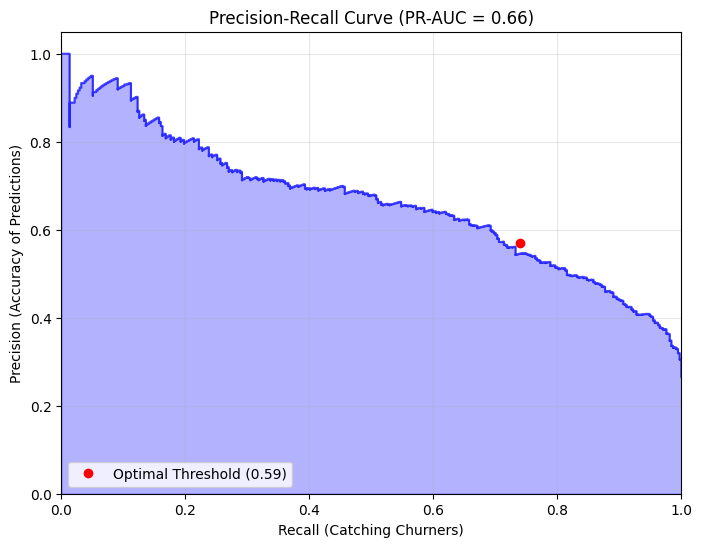

In [81]:
# 1. Calculate the Average Precision Score (PR-AUC)
average_precision = average_precision_score(y_test, y_scores)

# 2. Get the points for the curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Plotting the results
plt.figure(figsize=(8, 6))
plt.step(recalls, precisions, color='b', alpha=0.7, where='post')
plt.fill_between(recalls, precisions, step='post', alpha=0.3, color='b')

# Mark your "Optimal Threshold" (0.59) on the curve
# We find the index closest to your chosen recall/precision
plt.plot(0.74, 0.57, 'ro', label='Optimal Threshold (0.59)') 

plt.xlabel('Recall (Catching Churners)')
plt.ylabel('Precision (Accuracy of Predictions)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'Precision-Recall Curve (PR-AUC = {average_precision:.2f})')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

In [82]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Set minimum precision you want
target_precision = 0.70

# Find indices where precision >= target
valid_idx = np.where(precisions >= target_precision)[0]

# Get best threshold among them (highest recall)
best_idx = valid_idx[np.argmax(recalls[valid_idx])]
best_threshold = thresholds[best_idx]

# Apply threshold
y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(f"New Threshold: {best_threshold:.2f}")
print(classification_report(y_test, y_pred_optimal))

New Threshold: 0.79
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1033
           1       0.70      0.39      0.50       374

    accuracy                           0.79      1407
   macro avg       0.76      0.67      0.69      1407
weighted avg       0.78      0.79      0.77      1407



In [83]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get predicted probabilities
y_scores = best_model.predict_proba(X_test_adv)[:, 1]

# 2. Set custom threshold
threshold = 0.6

# 3. Convert probabilities to class predictions
y_pred_custom = (y_scores >= threshold).astype(int)

# 4. Evaluation
print(f"Using Threshold: {threshold}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_custom))

Using Threshold: 0.6

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.81      0.84      1033
           1       0.57      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407


Confusion Matrix:

[[834 199]
 [108 266]]


In [84]:
for t in [0.5, 0.55, 0.57, 0.6]:
    y_pred = (y_scores >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407


Threshold: 0.55
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1033
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407


Threshold: 0.57
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80 

In [88]:
import shap
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

# 1. Initialize JS visualization for Jupyter
shap.initjs()

# 2. Extract the actual model (Handling GridSearch if present)
if hasattr(best_model, 'best_estimator_'):
    actual_model = best_model.best_estimator_
else:
    actual_model = best_model

# 3. Clean the Test Data (Force float to avoid type errors)
X_test_clean = X_test.astype(float)

# ==========================================
# THE BYPASS: NATIVE XGBOOST SHAP CALCULATION
# ==========================================

# 4. Get the raw underlying XGBoost Booster object
booster = actual_model.get_booster()

# 5. Convert the test data into XGBoost's native DMatrix format
# We explicitly pass the feature names so XGBoost knows exactly what is what
dtrain = xgb.DMatrix(X_test_clean.values, feature_names=X_test_clean.columns.tolist())

# 6. Ask XGBoost to calculate the SHAP values internally (bypassing the shap library wrapper)
shap_contribs = booster.predict(dtrain, pred_contribs=True)

# 7. XGBoost returns SHAP values + 1 extra column at the very end for the 'bias' (expected value).
# We slice the array to keep all rows (:), but drop the last column (:-1)
shap_values_native = shap_contribs[:, :-1]

# ==========================================
# VISUALIZATION
# ==========================================

print("--- Global Feature Importance (Calculated Natively) ---")

# 8. Pass our natively calculated SHAP values to the summary plot
shap.summary_plot(shap_values_native, X_test_clean)

ValueError: feature_names mismatch: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Services', 'Is_Solo', 'Is_Auto_Pay', 'Short_Contract', 'Charge_Spike', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Charge_Tenure_Ratio', 'Service_Stickiness', 'High_Value_At_Risk'] ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Services', 'Is_Solo', 'Is_Auto_Pay', 'Short_Contract', 'Charge_Spike', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
expected High_Value_At_Risk, Service_Stickiness, Charge_Tenure_Ratio in input data

✅ Test data aligned with model features.
Test data shape: (1407, 24)
Model feature count: 24



--- Global Feature Importance (Overall Churn Drivers) ---


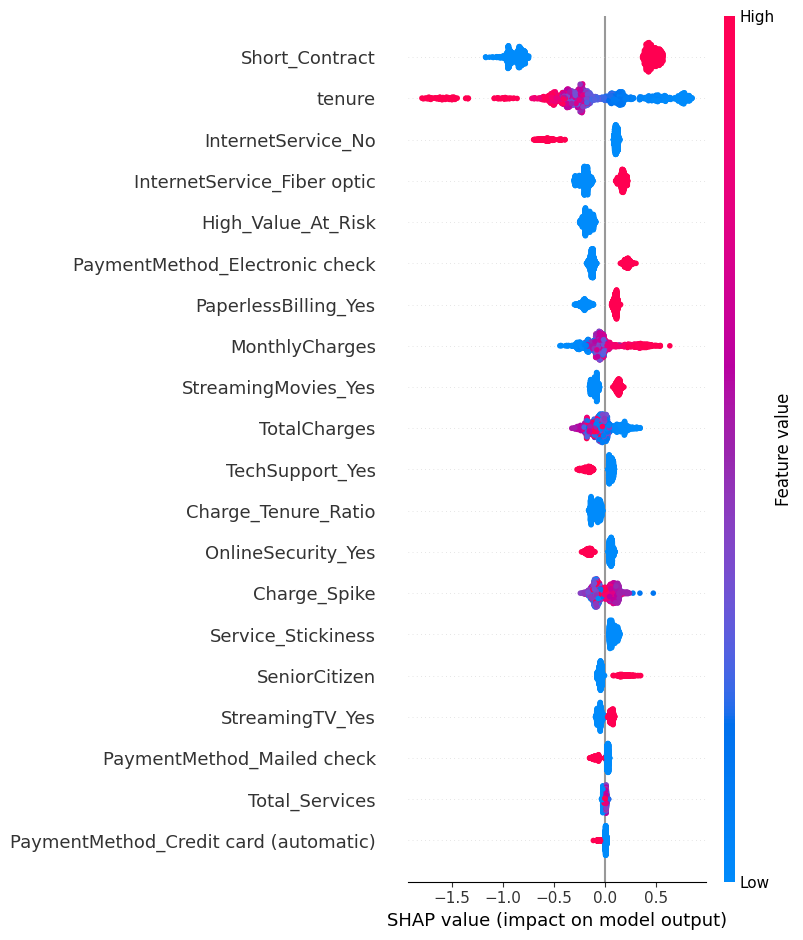


--- Local Interpretation (Customer index 0) ---


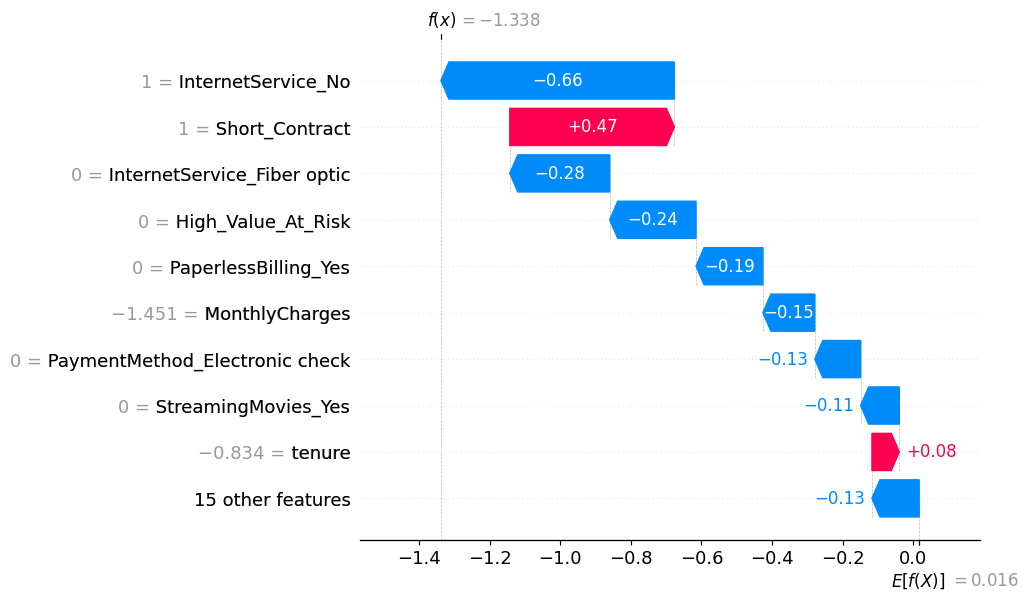


--- Error Analysis: Isolating Misclassifications ---
Total False Positives (False Alarms): 199
Total False Negatives (Missed Churners): 108

Sample False Positives for EDA:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Total_Services,Is_Solo,Is_Auto_Pay,Short_Contract,Charge_Spike,InternetService_Fiber optic,...,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Charge_Tenure_Ratio,Service_Stickiness,High_Value_At_Risk,Actual_Churn,Predicted_Churn
2047,0.0,0.631257,1.298142,1.164293,4.0,1.0,0.0,1.0,0.301195,1.0,...,1.0,1.0,0.0,1.0,0.0,0,0,0,0,1
2571,0.0,0.834744,1.444218,1.597952,5.0,0.0,1.0,1.0,-1.426282,1.0,...,1.0,1.0,0.0,0.0,0.0,0,0,0,0,1
2393,0.0,-1.240830,-1.145313,-0.976402,1.0,0.0,0.0,1.0,-0.618981,0.0,...,0.0,1.0,0.0,0.0,1.0,0,0,0,0,1
2271,1.0,0.468466,1.308101,0.966811,4.0,0.0,0.0,1.0,0.745975,1.0,...,1.0,0.0,0.0,1.0,0.0,0,0,0,0,1
6020,0.0,-1.159434,1.001010,-0.846267,4.0,1.0,0.0,1.0,1.813798,1.0,...,1.0,1.0,0.0,0.0,1.0,0,0,0,0,1



Sample False Negatives for EDA:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Total_Services,Is_Solo,Is_Auto_Pay,Short_Contract,Charge_Spike,InternetService_Fiber optic,...,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Charge_Tenure_Ratio,Service_Stickiness,High_Value_At_Risk,Actual_Churn,Predicted_Churn
6751,0.0,0.102189,-0.323635,-0.122807,1.0,1.0,0.0,1.0,-0.936133,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0,0,1,0
2096,0.0,0.183584,1.143766,0.641890,4.0,0.0,0.0,0.0,-0.871563,1.0,...,1.0,1.0,0.0,1.0,0.0,0,0,0,1,0
4167,0.0,0.183584,-1.200092,-0.577490,1.0,1.0,1.0,1.0,0.863956,0.0,...,0.0,0.0,1.0,0.0,0.0,0,0,0,1,0
6736,0.0,-1.159434,-0.273836,-0.901271,2.0,0.0,0.0,1.0,-0.866760,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0,0,1,0
6528,0.0,1.526602,1.689891,2.489671,6.0,0.0,1.0,0.0,0.682228,1.0,...,1.0,0.0,1.0,0.0,0.0,0,0,0,1,0


In [89]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# PART 0: PREPARE ACTUAL MODEL
# ==========================================

# If using GridSearchCV, extract the inner model
if hasattr(best_model, 'best_estimator_'):
    actual_model = best_model.best_estimator_
else:
    actual_model = best_model

# ==========================================
# PART 1: CLEAN & ALIGN TEST DATA
# ==========================================

# Force all test columns to float to avoid XGBoost type errors
X_test_clean = X_test.astype(float)

# Align test data columns to model's training features
model_features = actual_model.get_booster().feature_names

# Add missing columns with zeros
for col in model_features:
    if col not in X_test_clean.columns:
        X_test_clean[col] = 0

# Ensure columns are in the same order as the model
X_test_clean = X_test_clean[model_features]

print("✅ Test data aligned with model features.")
print(f"Test data shape: {X_test_clean.shape}")
print(f"Model feature count: {len(model_features)}")

# ==========================================
# PART 2: SHAP INTERPRETATION
# ==========================================

# 1. Initialize JS visualization
shap.initjs()

# 2. Create SHAP explainer
explainer = shap.TreeExplainer(actual_model)

# 3. Calculate SHAP values (modern API returns Explanation object)
shap_values = explainer(X_test_clean)

# 4. Global feature importance (summary plot)
print("\n--- Global Feature Importance (Overall Churn Drivers) ---")
shap.summary_plot(shap_values, X_test_clean)

# 5. Local explanation (waterfall plot) for the first row
row_index = 0
print(f"\n--- Local Interpretation (Customer index {row_index}) ---")
shap.waterfall_plot(shap_values[row_index])

# ==========================================
# PART 3: ERROR ANALYSIS
# ==========================================

print("\n--- Error Analysis: Isolating Misclassifications ---")

# Copy test data
error_analysis_df = X_test_clean.copy()

# Add actual and predicted values
error_analysis_df['Actual_Churn'] = y_test
error_analysis_df['Predicted_Churn'] = y_pred

# False Positives: predicted churn but stayed
false_positives = error_analysis_df[
    (error_analysis_df['Predicted_Churn'] == 1) &
    (error_analysis_df['Actual_Churn'] == 0)
]

# False Negatives: predicted stay but churned
false_negatives = error_analysis_df[
    (error_analysis_df['Predicted_Churn'] == 0) &
    (error_analysis_df['Actual_Churn'] == 1)
]

print(f"Total False Positives (False Alarms): {len(false_positives)}")
print(f"Total False Negatives (Missed Churners): {len(false_negatives)}")

print("\nSample False Positives for EDA:")
display(false_positives.head())

print("\nSample False Negatives for EDA:")
display(false_negatives.head())

Here’s a clear and concise summary of the **first SHAP plot (the waterfall plot for one customer)** based on what you shared, focused on the main takeaways:

---

### Summary of the Waterfall Plot (Local Explanation for One Customer)

- **Purpose:** Shows how each feature influenced the model’s churn prediction for a single customer.

- **Base Value:** The starting point — the average prediction for all customers without any specific info.

- **Feature Contributions:**
  - Features pushing the prediction **down (blue bars)** decrease this customer’s chance of churn.
  - Features pushing the prediction **up (red bars)** increase this customer’s chance of churn.

- **Key Features for This Customer:**
  - `InternetService_No` (Yes) strongly **reduces** churn risk for this customer.
  - `Short_Contract` (Yes) significantly **increases** churn risk.
  - Other features like `MonthlyCharges` and `High_Value_At_Risk` slightly lower the churn risk.

- **Final Prediction:** The model combines all these pushes and pulls to give the overall churn risk estimate for this customer (shown at the top).

---

### What this means practically:
For this specific customer, the model believes:

- Having no internet service is protective (less chance to churn).  
- Being on a short contract is risky (more chance to churn).  
- Overall, the churn risk is adjusted by all these features’ influences.

---

If you want, I can help you with summaries for the second plot or anything else!

# SHAP Waterfall Plot: Individual Customer Analysis

This plot explains the prediction for **one specific customer**. While the previous global plot showed feature importance across the entire dataset, this waterfall plot highlights how features **push the prediction up or down** for an individual.

Think of it as a **tug-of-war**:

- **Red arrows**: Features increasing the predicted churn risk.  
- **Blue arrows**: Features reducing the predicted churn risk.

---

## Understanding the Numbers

- **Base Value:** $E[f(X)] = 0.016$ (bottom right)  
  The average prediction of the model across all customers.

- **Final Prediction:** $f(x) = -1.338$ (top left)  
  Much lower than the base value, indicating a **very low probability of churn** for this customer.

---

## Feature Contributions (Tug-of-War)

### Factors Reducing Churn Risk (Blue Arrows)
These features **pull the score down**, making the customer more loyal:

| Feature | Value | Impact on Score |
|---------|-------|----------------|
| `InternetService_No` | 1 | -0.66 |
| `InternetService_Fiber optic` | 0 | -0.28 |
| `High_Value_At_Risk` | 0 | -0.24 |
| `MonthlyCharges` | -1.451 | -0.15 |

### Factors Increasing Churn Risk (Red Arrows)
These features **push the score up**, making the customer slightly more likely to churn:

| Feature | Value | Impact on Score |
|---------|-------|----------------|
| `Short_Contract` | 1 | +0.47 |
| `tenure` | -0.834 | +0.08 |

---

## Summary

This customer is **predicted to stay**.  

Even though `Short_Contract` slightly increases risk, the absence of internet service and low monthly charges **strongly outweigh the risk**, resulting in a **final prediction of -1.338**, which indicates a **very low probability of churn**.

--- BUSINESS IMPACT ANALYSIS ---
Profit at Default 0.50 Threshold: $85,580.00
Optimal Probability Threshold:    0.10
Maximized Profit:                 $159,780.00
Total Added Value:                $74,200.00



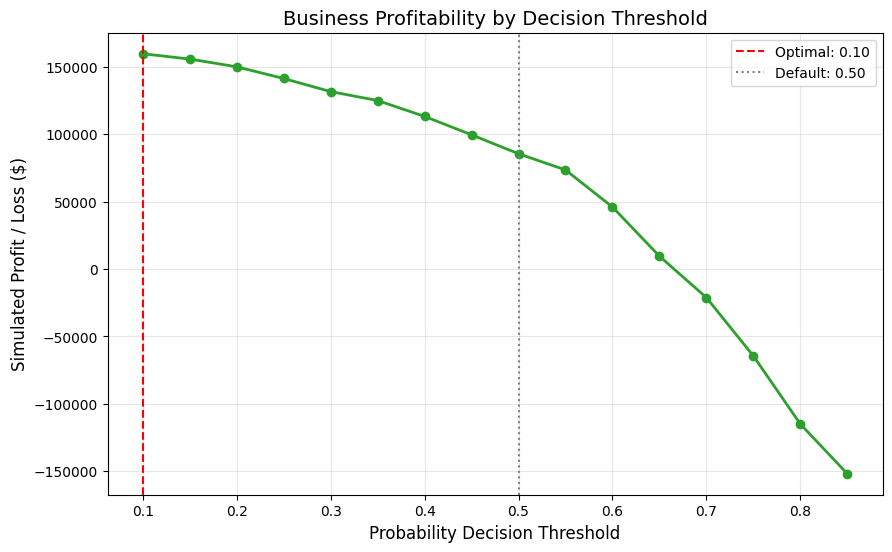

In [92]:
# ==========================================
# STEP 1: FIX THE MISSING COLUMNS
# ==========================================
# The model DEMANDS these 3 columns to exist before it will predict anything.
X_test['Charge_Tenure_Ratio'] = X_test['MonthlyCharges'] / (X_test['tenure'] + 1)

# ---> REPLACE THESE WITH OUR ACTUAL FORMULAS FROM YOUR EDA <---
# I am using placeholder math just so the code won't crash!
if 'Service_Stickiness' not in X_test.columns:
    X_test['Service_Stickiness'] = X_test['Total_Services'] 
if 'High_Value_At_Risk' not in X_test.columns:
    X_test['High_Value_At_Risk'] = (X_test['MonthlyCharges'] > 70).astype(int) 

# ==========================================
# STEP 2: REBUILD DTRAIN PROPERLY
# ==========================================
# Extract the booster
if hasattr(best_model, 'best_estimator_'):
    booster = best_model.best_estimator_.get_booster()
else:
    booster = best_model.get_booster()

# Force the exact column order
expected_columns = booster.feature_names
X_test_aligned = X_test[expected_columns].astype(float)

# Rebuild dtrain with all 24 columns
dtrain = xgb.DMatrix(X_test_aligned.values, feature_names=expected_columns)

# ==========================================
# STEP 3: BUSINESS THRESHOLD OPTIMIZATION
# ==========================================
# Now the prediction will work!
predicted_probabilities = booster.predict(dtrain)

# Define the Business Costs
cost_of_offer = 20    # Cost of a retention discount
cost_of_churn = 500   # Lost revenue from a churned customer

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
profits = []
y_actual = np.array(y_test) 

for threshold in thresholds:
    custom_predictions = (predicted_probabilities >= threshold).astype(int)
    
    TP = np.sum((custom_predictions == 1) & (y_actual == 1)) # Saved
    FP = np.sum((custom_predictions == 1) & (y_actual == 0)) # Wasted
    FN = np.sum((custom_predictions == 0) & (y_actual == 1)) # Lost
    
    financial_impact = (TP * (cost_of_churn - cost_of_offer)) - (FP * cost_of_offer) - (FN * cost_of_churn)
    profits.append(financial_impact)

# Find the best threshold
best_index = np.argmax(profits)
best_threshold = thresholds[best_index]
max_profit = profits[best_index]

default_index = list(np.round(thresholds, 2)).index(0.50)
default_profit = profits[default_index]

# ==========================================
# STEP 4: RESULTS & VISUALIZATION
# ==========================================
print(f"--- BUSINESS IMPACT ANALYSIS ---")
print(f"Profit at Default 0.50 Threshold: ${default_profit:,.2f}")
print(f"Optimal Probability Threshold:    {best_threshold:.2f}")
print(f"Maximized Profit:                 ${max_profit:,.2f}")
print(f"Total Added Value:                ${(max_profit - default_profit):,.2f}\n")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, marker='o', linewidth=2, color='#2ca02c')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Optimal: {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default: 0.50')

plt.title('Business Profitability by Decision Threshold', fontsize=14)
plt.xlabel('Probability Decision Threshold', fontsize=12)
plt.ylabel('Simulated Profit / Loss ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [93]:
import joblib

# 1. Create a dictionary to hold all your deployment assets
# We save the underlying actual model, not the GridSearch wrapper
deployment_package = {
    'model': actual_model,
    'optimal_threshold': best_threshold,
    'expected_columns': expected_columns,
    'business_metrics': {
        'max_profit': max_profit,
        'added_value': (max_profit - default_profit)
    }
}

# 2. Save (serialize) the package to your local hard drive
filename = 'xgboost_churn_model_production.pkl'
joblib.dump(deployment_package, filename)

print(f"✅ Success! Model securely packaged and saved as '{filename}'")

# ==========================================
# SIMULATION: HOW ENGINEERS WILL USE IT
# ==========================================
print("\n--- Simulating Production Load ---")

# This is exactly what the backend engineering team will code:
loaded_package = joblib.load(filename)
production_model = loaded_package['model']
prod_threshold = loaded_package['optimal_threshold']

print(f"Model loaded successfully. Enforcing business threshold of: {prod_threshold:.2f}")

# Engineers will now use: 
# probabilities = production_model.predict(new_customer_data)
# final_decisions = (probabilities >= prod_threshold).astype(int)

✅ Success! Model securely packaged and saved as 'xgboost_churn_model_production.pkl'

--- Simulating Production Load ---
Model loaded successfully. Enforcing business threshold of: 0.10
